<div style="padding:28px 34px;border-radius:16px;background:#6b1730;color:white;font-family:Arial,sans-serif"><div style="font-size:.84em;letter-spacing:2px;text-transform:uppercase">Module 1 · Notebook 2</div><h1 style="margin:7px 0">From the List ADT to an Array-Backed List</h1><p style="margin:0;font-size:1.12em">Start with the behavior we need; then examine one implementation and its costs.</p></div>

## From “a list” to the **List ADT**

In everyday programming, a list is an ordered collection that can grow and supports position-based operations. An **abstract data type (ADT)** captures that behavior without committing to a representation.

For this notebook, our List ADT promises:

- `add(item)` and `add(index, item)`
- `get(index)` and `set(index, item)`
- `remove(index)` and `remove(item)`
- `contains(item)` and `indexOf(item)`
- `clear()`, `size()`, and `isEmpty()`

The ADT describes **observable behavior**: valid indices, order, return values, and failure conditions. It does not say whether elements live in an array, nodes, a file, or a remote service.

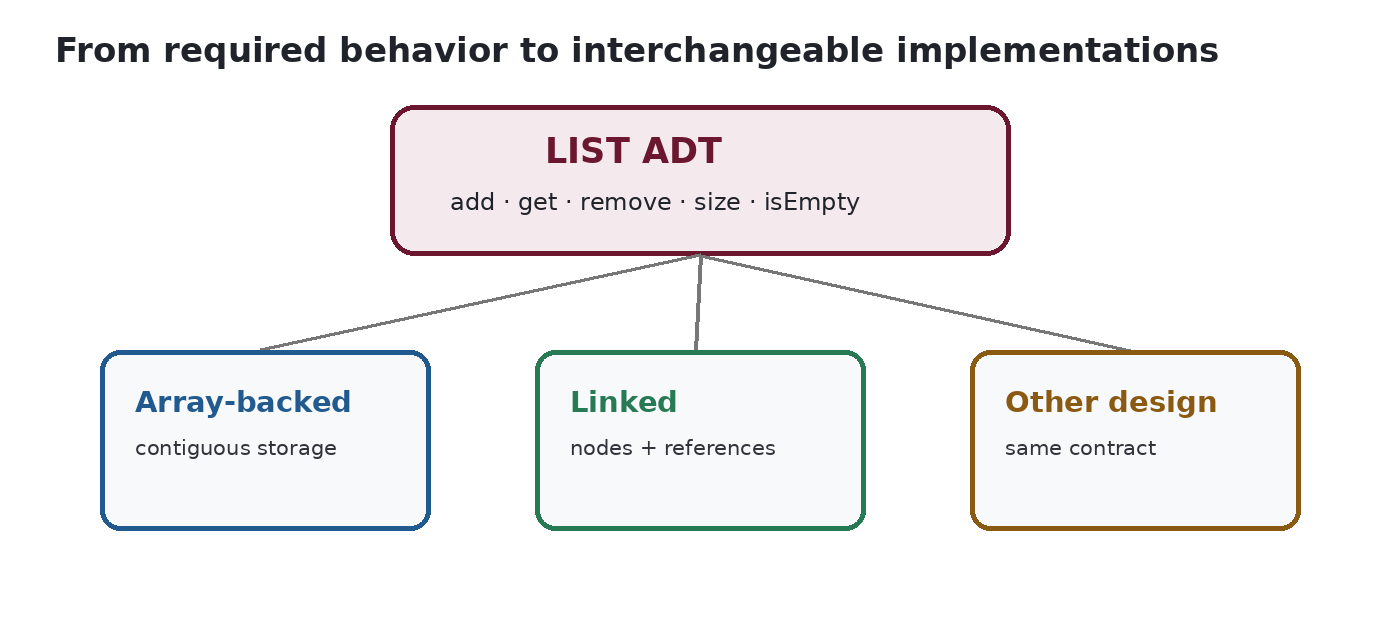

## Why abstraction is useful in real software

Applications should depend on the behavior they need, not unnecessary representation details. A scheduling component may need an ordered list of jobs; a user interface may need an ordered list of results; a service may expose a list of messages. If client code depends only on the List contract, engineers can change the storage strategy for scale, latency, or memory without rewriting every caller.

Abstraction also creates a testable boundary: every implementation can be checked against the same behavioral specification.

## Java expresses the contract with an `interface`

```java
public interface SimpleList {

    // Insertion
    void add(String item);              // append at the end
    void add(int index, String item);   // insert at index, shifting the rest right

    // Access
    String get(int index);              // element at index
    String set(int index, String item); // replace at index, return the old value

    // Removal
    String remove(int index);           // remove by position, return it
    boolean remove(String item);        // remove first occurrence, return whether found
    void clear();                       // remove everything

    // Query
    boolean contains(String item);      // is item present?
    int indexOf(String item);           // first position of item, or -1
    int size();                         // number of elements
    boolean isEmpty();                  // size() == 0
}
```

Index-taking methods throw `IndexOutOfBoundsException` for an out-of-range index — `add` accepts `0..size`; the others require `0..size-1`.

An ADT is the language-independent idea. A Java `interface` is a compiler-enforced mechanism for expressing that contract. A concrete class uses `implements SimpleList` and must provide every method.

In [ ]:
%%writefile SimpleList.java
/**
 * SimpleList: a minimal List ADT for teaching purposes.
 * Represents an ordered collection of String elements, indexed from 0.
 * Implementations decide HOW the elements are stored (array, linked
 * nodes, etc.) — this interface only defines WHAT the list can do.
 */
public interface SimpleList {

    // ----- Insertion -----

    /** Appends item to the end of the list. */
    void add(String item);

    /**
     * Inserts item at the given index, shifting elements at and after
     * index one position to the right.
     * @throws IndexOutOfBoundsException if index < 0 or index > size()
     */
    void add(int index, String item);

    // ----- Access -----

    /**
     * Returns the element stored at index.
     * @throws IndexOutOfBoundsException if index < 0 or index >= size()
     */
    String get(int index);

    /**
     * Replaces the element at index with item and returns the value
     * that was previously there.
     * @throws IndexOutOfBoundsException if index < 0 or index >= size()
     */
    String set(int index, String item);

    // ----- Removal -----

    /**
     * Removes and returns the element at index, shifting elements
     * after index one position to the left.
     * @throws IndexOutOfBoundsException if index < 0 or index >= size()
     */
    String remove(int index);

    /**
     * Removes the first occurrence of item from the list, if present.
     * @return true if an element was removed, false if item was not found
     */
    boolean remove(String item);

    /** Removes every element from the list. */
    void clear();

    // ----- Query -----

    /** Returns true if item appears anywhere in the list. */
    boolean contains(String item);

    /** Returns the index of the first occurrence of item, or -1 if not found. */
    int indexOf(String item);

    /** Returns the number of elements currently stored. */
    int size();

    /** Returns true if the list contains no elements. */
    boolean isEmpty();
}

## Client code depends on the ADT

The variable type is the interface; the object is the array-backed implementation:

```java
SimpleList names = new ArraySimpleList();
```

Client code can use only the operations promised by `SimpleList`. The linked implementation in Notebook 3 can replace `ArraySimpleList` at this single construction point without changing the rest of the client.

<div style="padding:28px 34px;border-radius:16px;background:#215a8e;color:white;font-family:Arial,sans-serif"><div style="font-size:.84em;letter-spacing:2px;text-transform:uppercase">Implementation 1</div><h1 style="margin:7px 0">Arrays</h1><p style="margin:0;font-size:1.12em">Compact, contiguous storage with constant-time indexed access.</p></div>

## Java arrays: simple and deliberately fixed

```java
int[] scores = new int[5];
String[] names = {"Amina", "Ben", "Cy"};
```

- Length is fixed at construction and read through the field `.length`.
- Every slot has one declared element type.
- Primitive arrays hold primitive values; reference arrays initially contain `null`.
- Indices start at `0`; invalid indices fail at runtime.

Unlike Python’s `list`, a Java array is not a growable collection. That constraint makes its layout predictable and its overhead small.

## Memory layout
![Memory hierarchy](figures/memory-hierarchy.svg)

![Contiguous array layout](figures/contiguous-array-layout.svg)

![Cache-friendly array access](figures/cache-friendly-array.svg)

## What the layout means for performance

- **Indexed access (`get`, `set`):** O(1); the address is computed directly.
- **Iteration:** usually cache-friendly because slots are contiguous.
- **Append with free capacity:** O(1).
- **Insert/remove near the front or middle:** O(n), because elements must shift.
- **Search (`contains`, `indexOf`):** O(n); every element may need checking.
- **Capacity:** may exceed logical size; unused slots consume memory.

For reference types, the array stores contiguous **references**; the referenced objects may live elsewhere in memory.

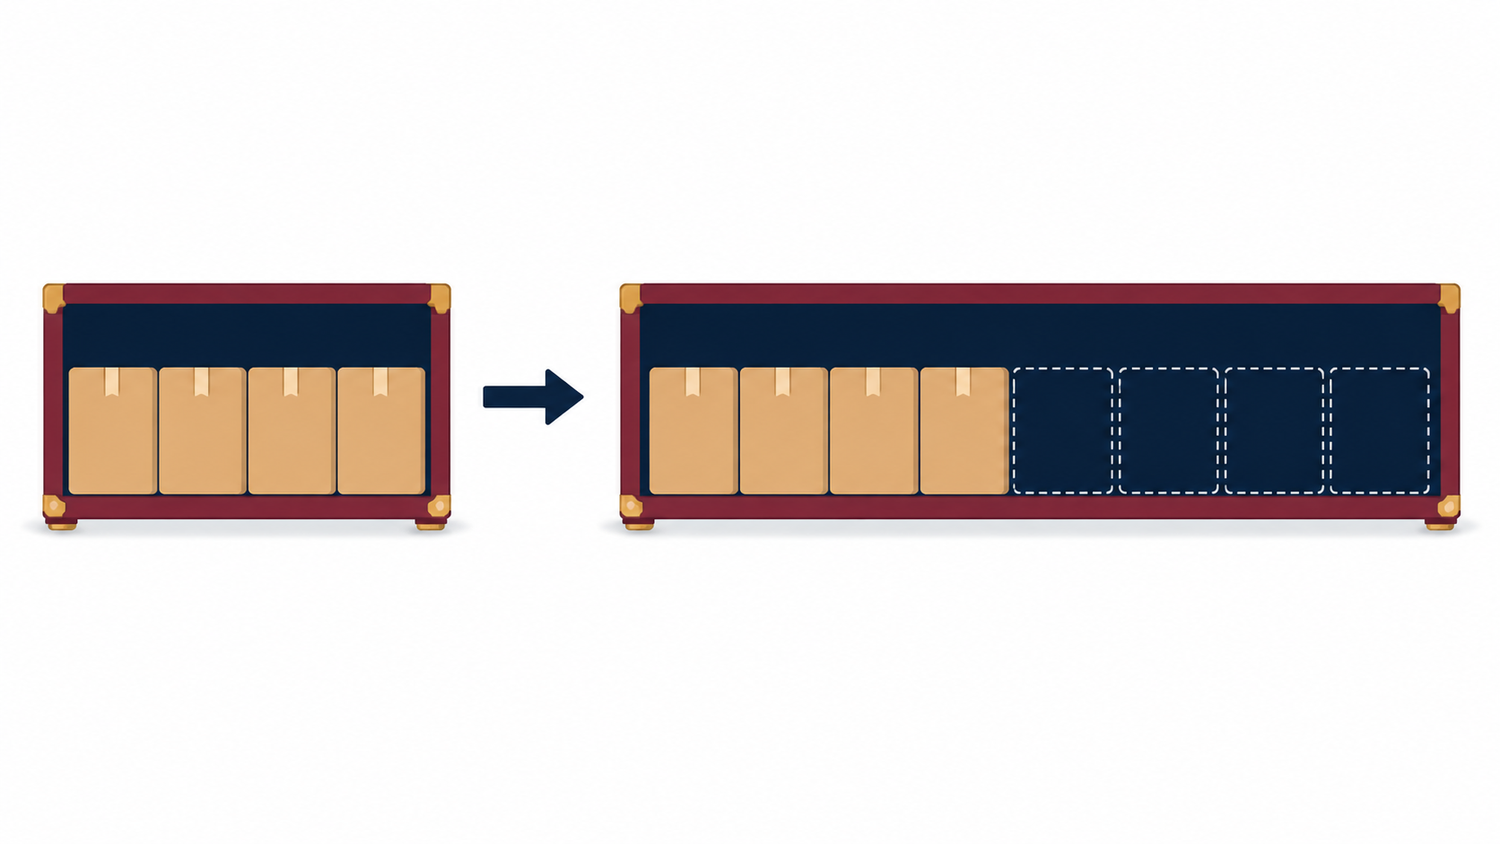

## Why resizing gives amortized O(1) append

When the backing array is full, allocate a larger array—commonly about twice the capacity—and copy the existing elements. That one append costs O(n), but resizing does not happen on every append.

With geometric growth, a long sequence of appends performs only O(n) total copying. We therefore describe append as **O(1) amortized**: not every operation is constant-time, but the average cost per operation over the sequence is bounded by a constant.

Engineering trade-off: a larger growth factor reduces copying but retains more unused memory; a smaller factor saves slack space but resizes more often.

## Java ships this design: `java.util.ArrayList`

You do not write the resizing array yourself. Java's standard library provides **`ArrayList`**, which *is* this design — a growable array with amortized O(1) append, O(1) indexed access, and O(n) insertion or removal away from the end.

`ArrayList` implements **`List`**, Java's general-purpose List ADT (the real interface behind our teaching `SimpleList`). Client code is written against `List`; only the constructor names `ArrayList`. Substituting `LinkedList` (Notebook 3) changes nothing else. Unlike `SimpleList`, `List<E>` is **generic**: the element type is a parameter, not fixed to `String`.

```java
import java.util.ArrayList;
import java.util.List;

List<String> names = new ArrayList<>();   // program to the interface; ArrayList is the implementation
// new ArrayList<>(64) would pre-size the backing array and skip the early resizes

names.add("Amina");                        // append — amortized O(1)
names.add("Cy");
names.add(1, "Ben");                       // insert at index 1 — O(n), shifts the rest right
String first = names.get(0);               // indexed access — O(1)
names.set(2, "Cyrus");                     // replace at index 2 — O(1)
names.remove("Ben");                       // remove first matching value — O(n)
boolean hasCy  = names.contains("Cy");     // linear search — O(n)
int whereCyrus = names.indexOf("Cyrus");   // linear search — O(n)

System.out.println(names + " size " + names.size());   // [Amina, Cyrus] size 2
```

Every call maps directly to an operation `SimpleList` promises, with the same cost profile — because `ArrayList` is backed by the same resizing-array idea developed above.

## When an array-backed list is an excellent choice

Choose it when the workload values:

- frequent indexed reads;
- fast sequential scans and good cache locality;
- mostly append-at-end updates;
- low per-element overhead;
- predictable, compact storage.

Question it when the workload repeatedly inserts or removes near the front or middle, requires stable references to elements, or cannot tolerate occasional resize latency spikes.

## Check your understanding

1. Why is the List ADT not the same thing as Java’s `List` interface?
2. What does using abstraction in DS buy us?
3. Why is indexed access O(1) in an array?
4. Why can a single append cost O(n), while append is still O(1) amortized?
5. What workload and memory characteristics favor an array-backed list?
6. Which `SimpleList` operations run in O(1) on `ArraySimpleList`, and which are O(n)?

**Next:** implement the same List contract with linked nodes and compare the engineering consequences.